In [1]:
import openmc
import numpy as np

def generate_smr160_assembly(enrichment=0.045, boron_ppm=600.0, rods_inserted=False, particles=10000, batches=50):
    """
    SMR-160 (Holtec) 17x17 GAIA Yakıt Demeti ve HARMONI Kontrol Çubukları
    - Tam Boy (144 inç / 365.76 cm) Aktif Yükseklik
    - Q12™ / M5® Kılavuz Tüpler (Artırılmış Yanal Sertlik)
    - %80 Ag, %15 In, %5 Cd AIC Kontrol Çubukları
    """
    print(f"SMR-160 (GAIA) Modeli Oluşturuluyor... (Zenginlik: %{enrichment*100}, Kontrol Çubukları: {'İçeride' if rods_inserted else 'Dışarıda'})")

    # 1. MALZEME TANIMLAMALARI (O16 İZOTOPUYLA)
    # 1.A. Standart UO2 Yakıtı
    fuel = openmc.Material(name='SMR160_UO2')
    fuel.set_density('g/cm3', 10.42)
    m_u = enrichment * 235.04 + (1.0 - enrichment) * 238.05
    m_o2 = 2 * 15.995
    m_uo2 = m_u + m_o2
    fuel.add_nuclide('U235', enrichment * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('U238', (1.0 - enrichment) * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('O16', m_o2 / m_uo2, 'wo')

    # 1.B. M5 Alaşımlı Kılıf
    clad = openmc.Material(name='SMR160_M5_Clad')
    clad.set_density('g/cm3', 6.55)
    clad.add_element('Zr', 0.9885, 'wo')
    clad.add_element('Nb', 0.0100, 'wo')
    clad.add_nuclide('O16', 0.0015, 'wo')

    # 1.C. Q12 Kılavuz Tüp Alaşımı (Sürünme dirençli özel M5 modifikasyonu)
    # M5 tabanlıdır, ancak minör kalay (Sn) ve demir (Fe) katkılarıyla sertleştirilmiştir
    q12_tube = openmc.Material(name='SMR160_Q12_Tube')
    q12_tube.set_density('g/cm3', 6.56)
    q12_tube.add_element('Zr', 0.9850, 'wo')
    q12_tube.add_element('Nb', 0.0100, 'wo')
    q12_tube.add_element('Sn', 0.0030, 'wo') # Sertleştir
    q12_tube.add_element('Fe', 0.0020, 'wo') # Sertleştirici

    # 1.D. HARMONI Kontrol Çubuğu Yutucusu (AIC: Ag-In-Cd)
    aic = openmc.Material(name='SMR160_AIC_Absorber')
    aic.set_density('g/cm3', 10.17)
    aic.add_element('Ag', 0.80, 'wo')
    aic.add_element('In', 0.15, 'wo') 
    aic.add_element('Cd', 0.05, 'wo') 

    # Paslanmaz Çelik 304 (Kontrol Çubuğu Kılıfı için)
    ss304 = openmc.Material(name='SMR160_SS304')
    ss304.set_density('g/cm3', 8.00)
    ss304.add_element('Fe', 0.68, 'wo')
    ss304.add_element('Cr', 0.19, 'wo')
    ss304.add_element('Ni', 0.10, 'wo')
    ss304.add_element('Mn', 0.02, 'wo')

    helium = openmc.Material(name='SMR160_Gap_He')
    helium.set_density('g/cm3', 0.001598)
    helium.add_element('He', 1.0)

    # 1.E. Borlu Soğutucu
    water = openmc.Material(name='SMR160_Water')
    water.set_density('g/cm3', 0.740582)
    water.temperature = 566.5
    
    boron_wt = boron_ppm * 1e-6
    water_wt = 1.0 - boron_wt
    m_H2O = 2 * 1.008 + 15.995
    water.add_element('H', water_wt * (2 * 1.008) / m_H2O, 'wo')
    water.add_nuclide('O16', water_wt * 15.995 / m_H2O, 'wo')
    water.add_element('B', boron_wt, 'wo')

    materials = openmc.Materials([fuel, clad, q12_tube, aic, ss304, helium, water])
    materials.export_to_xml()

    # 2. GEOMETRİK BOYUTLAR (Yarıçaplar)
    r_pellet = openmc.ZCylinder(r=0.39218)
    r_gap = openmc.ZCylinder(r=0.40005)
    r_clad = openmc.ZCylinder(r=0.45720)
    
    # Q12 Kılavuz Tüpü (Artırılmış yanal sertlik için kalınlaştırılmış cidar)
    r_gt_in = openmc.ZCylinder(r=0.56000)
    r_gt_out = openmc.ZCylinder(r=0.61500) # Cidar kalınlığı artırıldı

    # Kontrol Çubuğu Geometrisi (Kılavuz Tüpün içine girecek şekilde boyutlandırıldı)
    r_aic = openmc.ZCylinder(r=0.43000)  # AIC Yutucu Yarıçapı
    r_aic_gap = openmc.ZCylinder(r=0.44000) # Boşluk
    r_aic_clad = openmc.ZCylinder(r=0.48500) # SS304 Kılıf (Bunun ile tüp arasında su akar)

    # 3. HÜCRELER VE EVRENLER
    # 3.A. Yakıt Evreni (F)
    c_fuel = openmc.Cell(fill=fuel, region=-r_pellet)
    c_gap = openmc.Cell(fill=helium, region=+r_pellet & -r_gap)
    c_clad = openmc.Cell(fill=clad, region=+r_gap & -r_clad)
    c_water = openmc.Cell(fill=water, region=+r_clad)
    F = openmc.Universe(cells=[c_fuel, c_gap, c_clad, c_water])

    # 3.B. Boş Kılavuz Tüp Evreni (G) - Kontrol çubukları yukarı çekildiğinde
    c_g_inner = openmc.Cell(fill=water, region=-r_gt_in)
    c_g_clad = openmc.Cell(fill=q12_tube, region=+r_gt_in & -r_gt_out)
    c_g_water = openmc.Cell(fill=water, region=+r_gt_out)
    G = openmc.Universe(cells=[c_g_inner, c_g_clad, c_g_water])

    # 3.C. Dolu Kılavuz Tüp Evreni (C) - AIC Kontrol çubukları aşağı indiğinde (Inserted)
    c_c_aic = openmc.Cell(fill=aic, region=-r_aic)
    c_c_aic_gap = openmc.Cell(fill=helium, region=+r_aic & -r_aic_gap)
    c_c_aic_clad = openmc.Cell(fill=ss304, region=+r_aic_gap & -r_aic_clad)
    c_c_water_flow = openmc.Cell(fill=water, region=+r_aic_clad & -r_gt_in) # Çubuk ile tüp arası su
    c_c_q12 = openmc.Cell(fill=q12_tube, region=+r_gt_in & -r_gt_out)
    c_c_water_out = openmc.Cell(fill=water, region=+r_gt_out)
    C = openmc.Universe(cells=[c_c_aic, c_c_aic_gap, c_c_aic_clad, c_c_water_flow, c_c_q12, c_c_water_out])

    # Dinamik Karar Mekanizması
    X = C if rods_inserted else G

    # 4. MATRİS VE SINIRLAR
    rod_pitch = 1.25984
    offset = (17 * rod_pitch) / 2.0

    lattice = openmc.RectLattice()
    lattice.pitch = (rod_pitch, rod_pitch)
    lattice.lower_left = (-offset, -offset)
    
    # 17x17 GAIA Matrisi (24 Kontrol Pozisyonu X ile temsil edilir)
    lattice.universes = [
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, X, F, F, X, F, F, X, F, F, F, F, F],
        [F, F, F, X, F, F, F, F, F, F, F, F, F, X, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, X, F, F, X, F, F, X, F, F, X, F, F, X, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, X, F, F, X, F, F, G, F, F, X, F, F, X, F, F], 
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, X, F, F, X, F, F, X, F, F, X, F, F, X, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, X, F, F, F, F, F, F, F, F, F, X, F, F, F],
        [F, F, F, F, F, X, F, F, X, F, F, X, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F]
    ]
    lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

    # SMR-160 Tam Boy Yükseklik: 144 inç -> 365.76 cm
    min_x = openmc.XPlane(x0=-offset, boundary_type='reflective')
    max_x = openmc.XPlane(x0=offset, boundary_type='reflective')
    min_y = openmc.YPlane(y0=-offset, boundary_type='reflective')
    max_y = openmc.YPlane(y0=offset, boundary_type='reflective')
    min_z = openmc.ZPlane(z0=-182.88, boundary_type='reflective')
    max_z = openmc.ZPlane(z0=182.88, boundary_type='reflective')

    core_box = +min_x & -max_x & +min_y & -max_y & +min_z & -max_z
    main_cell = openmc.Cell(fill=lattice, region=core_box)
    geometry = openmc.Geometry([main_cell])
    geometry.export_to_xml()

    print("SMR-160 (Holtec) XML Dosyaları Başarıyla Üretildi.")
    return offset

In [2]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

smr160_offset = generate_smr160_assembly(
    enrichment=0.045, 
    boron_ppm=600.0, 
    rods_inserted=True, 
    particles=10000, 
    batches=60
)

print("\nSMR-160 Gelişmiş Sensörleri (Tallies) Kuruluyor.")

#  ENERJİ SPEKTRUMU SENSÖRÜ
energy_bins = np.logspace(-5, 7.3, 500)
energy_filter = openmc.EnergyFilter(energy_bins)
spectrum_tally = openmc.Tally(name='Notron_Spektrumu')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']

# YÜKSEK ÇÖZÜNÜRLÜKLÜ ISI HARİTALARI (170x170)
spatial_mesh = openmc.RegularMesh()
spatial_mesh.dimension = [170, 170]
spatial_mesh.lower_left = [-smr160_offset, -smr160_offset]
spatial_mesh.upper_right = [smr160_offset, smr160_offset]

spatial_tally = openmc.Tally(name='Uzamsal_Haritalar')
spatial_tally.filters = [openmc.MeshFilter(spatial_mesh)]
spatial_tally.scores = ['flux', 'fission', 'absorption']

#  PİN-BY-PİN GÜÇ SENSÖRÜ (17x17)
pin_mesh = openmc.RegularMesh()
pin_mesh.dimension = [17, 17]
pin_mesh.lower_left = [-smr160_offset, -smr160_offset]
pin_mesh.upper_right = [smr160_offset, smr160_offset]

pin_tally = openmc.Tally(name='Pin_Gucu')
pin_tally.filters = [openmc.MeshFilter(pin_mesh)]
pin_tally.scores = ['kappa-fission']

#  KÜRESEL REAKSİYON İSTATİSTİKLERİ VE ENTROPİ
reaction_tally = openmc.Tally(name='Global_Reaksiyonlar')
reaction_tally.scores = ['(n,2n)', '(n,gamma)']

entropy_mesh = openmc.RegularMesh()
entropy_mesh.dimension = [17, 17, 1]
# SMR-160 Tam Boy Yükseklik: Z ekseni -182.88'den +182.88'e
entropy_mesh.lower_left = [-smr160_offset, -smr160_offset, -182.88]
entropy_mesh.upper_right = [smr160_offset, smr160_offset, 182.88]

settings = openmc.Settings.from_xml()
settings.entropy_mesh = entropy_mesh
settings.export_to_xml()

tallies = openmc.Tallies([spectrum_tally, spatial_tally, pin_tally, reaction_tally])
tallies.export_to_xml()

print("\n--- SMR-160 (HOLTEC) K-EIGENVALUE VE ANALİZ SİMÜLASYONU BAŞLIYOR ---\n")
openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
openmc.run(output=True)

SMR-160 (GAIA) Modeli Oluşturuluyor... (Zenginlik: %4.5, Kontrol Çubukları: İçeride)
SMR-160 (Holtec) XML Dosyaları Başarıyla Üretildi.

SMR-160 Gelişmiş Sensörleri (Tallies) Kuruluyor.

--- SMR-160 (HOLTEC) K-EIGENVALUE VE ANALİZ SİMÜLASYONU BAŞLIYOR ---



/home/busra/miniconda3/envs/openmc/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=6.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

SMR-160 Reaktör Kesiti Yüksek Çözünürlükle Çiziliyor.
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%

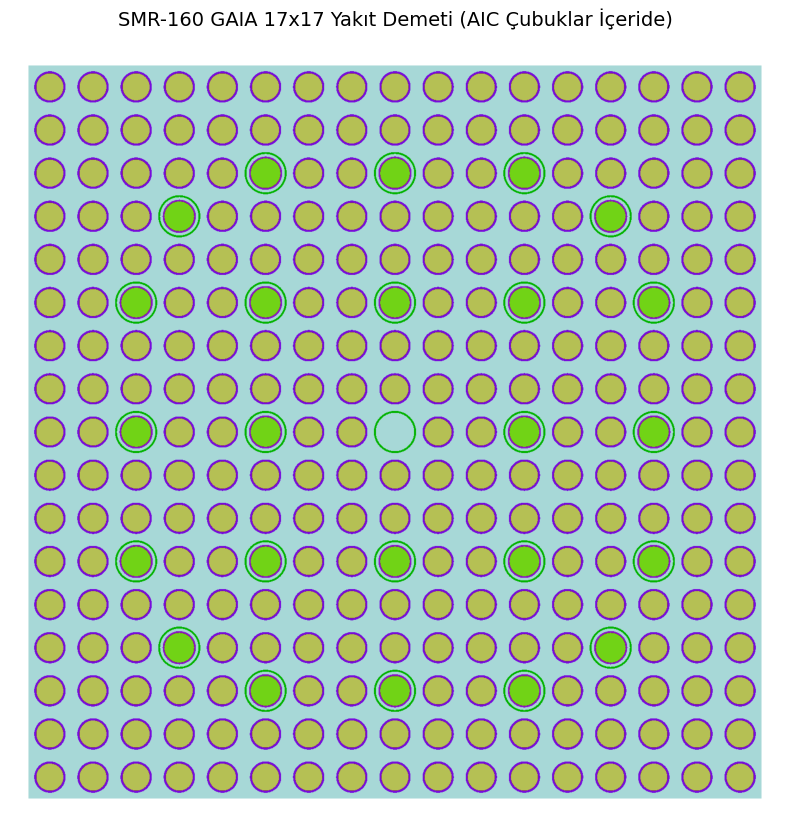

In [3]:
import matplotlib.image as mpimg

print("SMR-160 Reaktör Kesiti Yüksek Çözünürlükle Çiziliyor.")

plot = openmc.Plot()
plot.filename = 'smr160_radial_plot'
width = smr160_offset * 2.1
plot.width = (width, width)
plot.pixels = (1500, 1500)
plot.basis = 'xy'
plot.origin = (0.0, 0.0, 0.0)
plot.color_by = 'material' 

plots = openmc.Plots([plot])
plots.export_to_xml()
openmc.plot_geometry()

try:
    img = mpimg.imread('smr160_radial_plot.png')
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('SMR-160 GAIA 17x17 Yakıt Demeti (AIC Çubuklar İçeride)', fontsize=14, pad=15)
    plt.show()
except FileNotFoundError:
    print("Çizim dosyası bulunamadı.")


Sonuçlar HDF5 Dosyasından Çekiliyor.



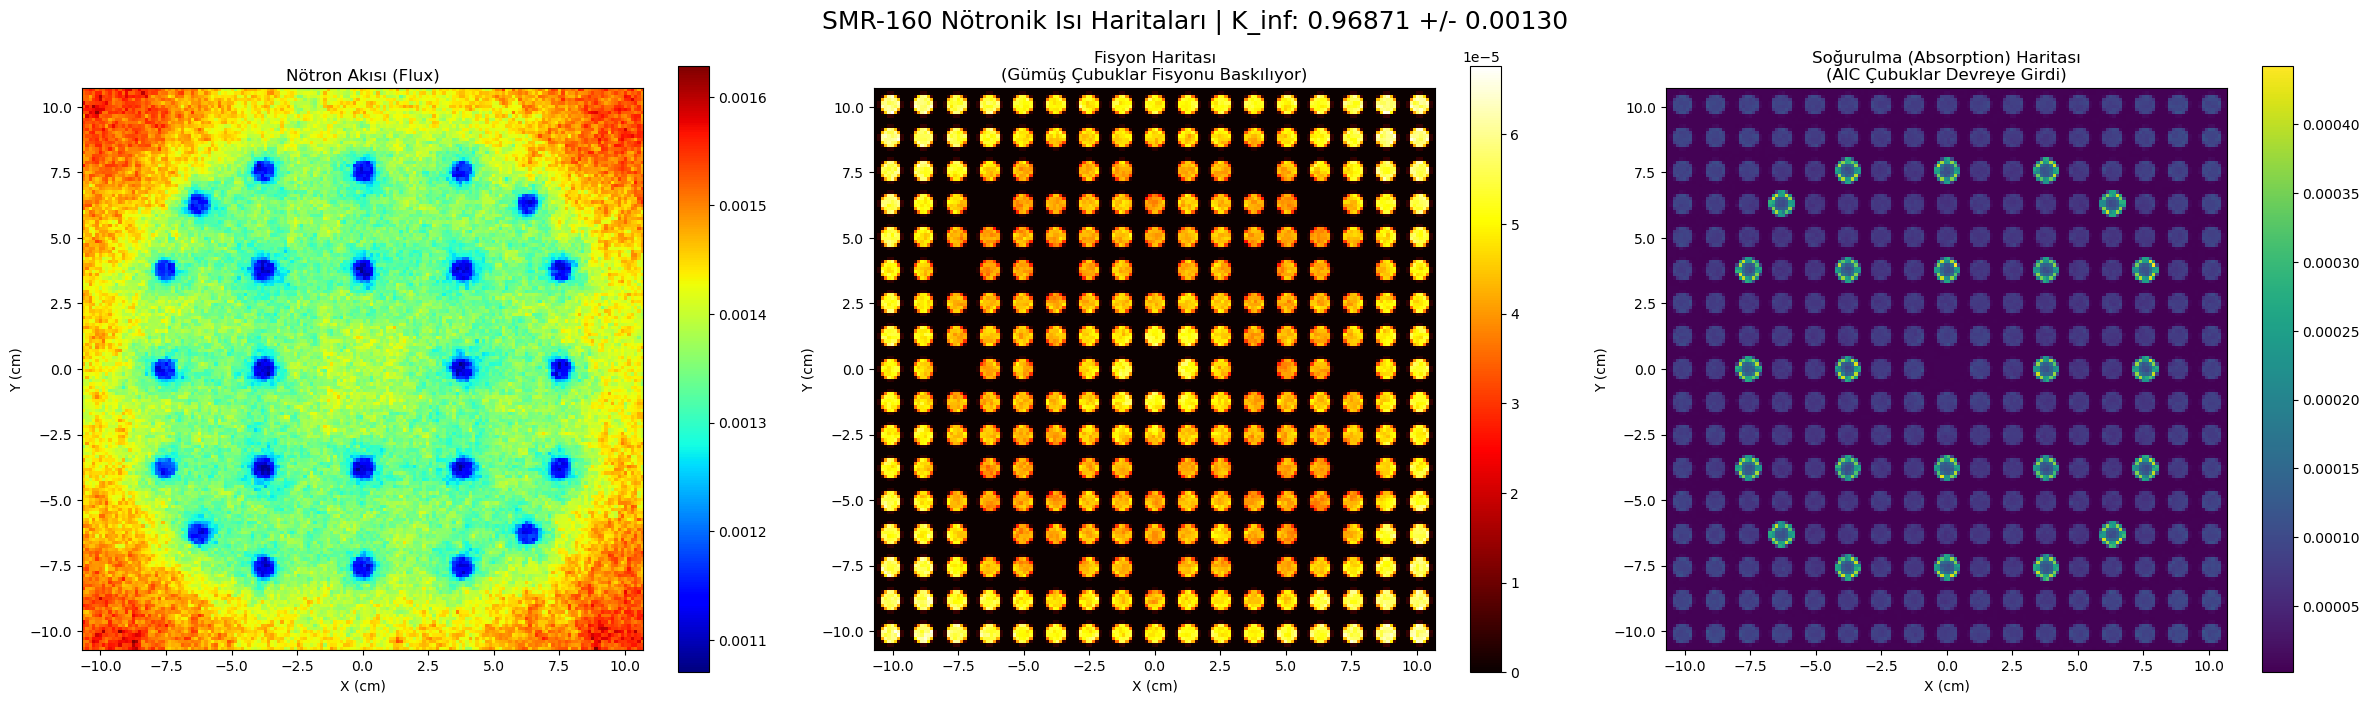

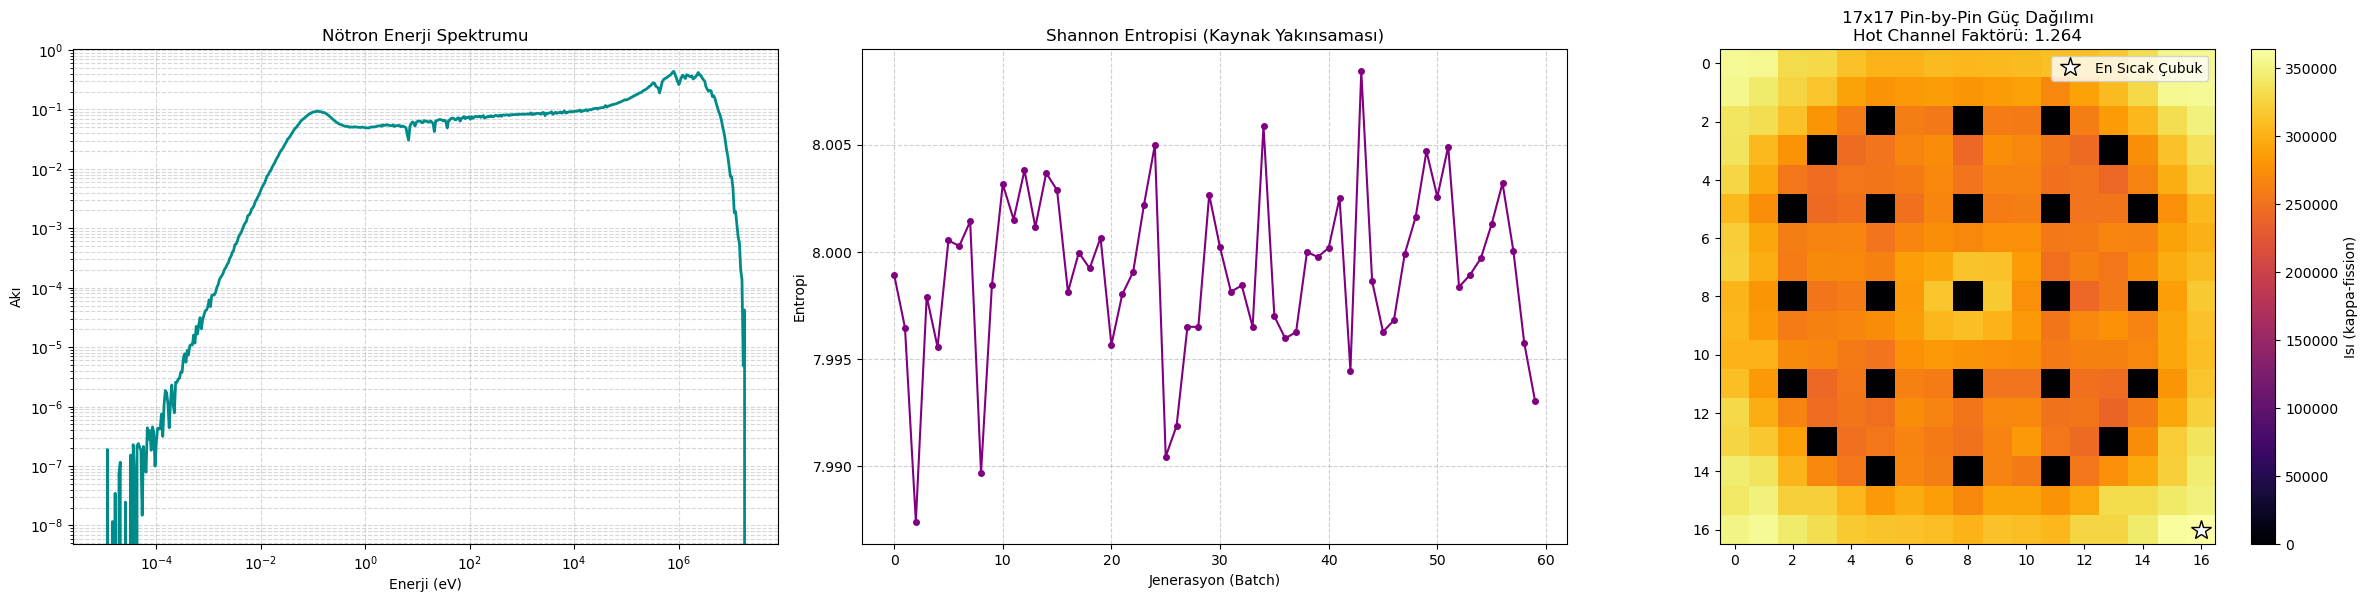

  SMR-160 (GAIA/HARMONI) REAKSİYON İSTATİSTİKLERİ
K-Effective (Sonsuz Çoğalma)  : 0.96871 +/- 0.00130
Hot Channel (Güç Zirve) Oranı : 1.264
Toplam (n,2n) Çoğalma Oranı   : 1.42811e-03
Toplam (n,gamma) Yutulma Oranı: 5.76840e-01


In [4]:
import h5py

print("\nSonuçlar HDF5 Dosyasından Çekiliyor.\n")
statepoint_files = glob.glob('statepoint.*.h5')
latest_sp = max(statepoint_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    k_inf = sp.keff
    entropy = sp.entropy
    
    # Spektrum
    spec_t = sp.get_tally(name='Notron_Spektrumu')
    flux_spectrum = spec_t.mean.flatten()
    
    # 170x170 Isı Haritaları
    spatial_t = sp.get_tally(name='Uzamsal_Haritalar')
    flux_map = spatial_t.get_slice(scores=['flux']).mean.reshape((170, 170))
    fission_map = spatial_t.get_slice(scores=['fission']).mean.reshape((170, 170))
    abs_map = spatial_t.get_slice(scores=['absorption']).mean.reshape((170, 170))
    
    # 17x17 Pin Gücü ve Reaksiyonlar
    pin_t = sp.get_tally(name='Pin_Gucu')
    power_map = pin_t.get_slice(scores=['kappa-fission']).mean.reshape((17, 17))
    
    rxn_t = sp.get_tally(name='Global_Reaksiyonlar')
    n2n_rate = rxn_t.get_slice(scores=['(n,2n)']).mean.sum()
    ngamma_rate = rxn_t.get_slice(scores=['(n,gamma)']).mean.sum()

# Harita Yönlerini Düzeltme
flux_map, fission_map, abs_map, power_map = map(np.flipud, [flux_map, fission_map, abs_map, power_map])
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

# Hot Channel Factor Hesabı
avg_power = np.mean(power_map[power_map > 0])
max_power = np.max(power_map)
hot_channel_factor = max_power / avg_power

ext = [-smr160_offset, smr160_offset, -smr160_offset, smr160_offset]
fig1, axes1 = plt.subplots(1, 3, figsize=(24, 7))
fig1.suptitle(f'SMR-160 Nötronik Isı Haritaları | K_inf: {k_inf.nominal_value:.5f} +/- {k_inf.std_dev:.5f}', fontsize=18)

im0 = axes1[0].imshow(flux_map, interpolation='nearest', cmap='jet', extent=ext)
axes1[0].set_title('Nötron Akısı (Flux)')
fig1.colorbar(im0, ax=axes1[0])

im1 = axes1[1].imshow(fission_map, interpolation='nearest', cmap='hot', extent=ext)
axes1[1].set_title('Fisyon Haritası\n(Gümüş Çubuklar Fisyonu Baskılıyor)')
fig1.colorbar(im1, ax=axes1[1])

im2 = axes1[2].imshow(abs_map, interpolation='nearest', cmap='viridis', extent=ext)
axes1[2].set_title('Soğurulma (Absorption) Haritası\n(AIC Çubuklar Devreye Girdi)')
fig1.colorbar(im2, ax=axes1[2])

for ax in axes1: ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)')
plt.tight_layout()
plt.show()

#SPEKTRUM, ENTROPİ VE PİN GÜCÜ
fig2, axes2 = plt.subplots(1, 3, figsize=(24, 6))

# Spektrum
axes2[0].loglog(energy_centers, flux_spectrum, color='darkcyan', linewidth=2)
axes2[0].set_title('Nötron Enerji Spektrumu')
axes2[0].set_xlabel('Enerji (eV)')
axes2[0].set_ylabel('Akı')
axes2[0].grid(True, which="both", ls="--", alpha=0.5)

# Entropi
axes2[1].plot(entropy, marker='o', color='purple', markersize=4)
axes2[1].set_title('Shannon Entropisi (Kaynak Yakınsaması)')
axes2[1].set_xlabel('Jenerasyon (Batch)')
axes2[1].set_ylabel('Entropi')
axes2[1].grid(True, linestyle='--', alpha=0.6)

# Pin Gücü
im_pin = axes2[2].imshow(power_map, interpolation='nearest', cmap='inferno')
axes2[2].set_title(f'17x17 Pin-by-Pin Güç Dağılımı\nHot Channel Faktörü: {hot_channel_factor:.3f}')
fig2.colorbar(im_pin, ax=axes2[2], label='Isı (kappa-fission)')
max_idx = np.unravel_index(np.argmax(power_map), power_map.shape)
axes2[2].plot(max_idx[1], max_idx[0], 'w*', markersize=15, markeredgecolor='black', label='En Sıcak Çubuk')
axes2[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("="*55)
print("  SMR-160 (GAIA/HARMONI) REAKSİYON İSTATİSTİKLERİ")
print("="*55)
print(f"K-Effective (Sonsuz Çoğalma)  : {k_inf.nominal_value:.5f} +/- {k_inf.std_dev:.5f}")
print(f"Hot Channel (Güç Zirve) Oranı : {hot_channel_factor:.3f}")
print(f"Toplam (n,2n) Çoğalma Oranı   : {n2n_rate:.5e}")
print(f"Toplam (n,gamma) Yutulma Oranı: {ngamma_rate:.5e}")
print("="*55)